# 6 - accDM daughter: fluid approximation vs exact Boltzmann hierarchy

Two ways to evolve the accDM daughter:
- **exact** - full Boltzmann hierarchy (`ncdm_fluid_approximation = none`): accurate, `O(N_q x l_max)` equations, slow.
- **fluid** - daughter as a fluid (`ncdm_fluid_approximation = CLASS`): a few equations, fast, approximate.

**The catch (stiffness at switch-on).** When the fluid turns on, the daughter's converted `delta`/`theta` are not on the fluid attractor, and the source `a*Gamma*ratio_rho*(theta - 3/4 theta_dcdm)` forces a near-instant relaxation. `ratio_rho ~ 1/trigger` at switch-on, so a small trigger (early, useful switch-on) makes the transient unresolvable for the explicit `rk` evolver (`step too small`); `ndf15` would handle it but segfaults. The fluid is therefore only usable for *large* triggers (late switch-on, little speedup).

This notebook (a) times the **exact** hierarchy across `kappa` (the production code path), and (b) **scans the fluid trigger** at a representative `kappa` to map the usable boundary and the agreement/speedup trade-off. Runs are wrapped in try/except - a fluid crash is recorded, not fatal.

Hybrid: hard asserts (exact must run; fluid must agree where it runs) + plots.

In [1]:
import time
import tqdm as tqdm
import numpy as np
import matplotlib.pyplot as plt
from classy import Class

plt.rcParams.update({
    'mathtext.fontset': 'stix', 'font.family': 'serif', 'font.size': 11,
    'axes.labelsize': 12, 'legend.fontsize': 9, 'lines.linewidth': 1.5, 'figure.dpi': 300})
qual_colors = ['#377eb8', '#ff7f00', '#4daf4a', '#f781bf', '#984ea3']

LMAX = 2000
K_NODES = np.logspace(-3, 0.9, 50)   # 1/Mpc

omega_b    = 0.022383
omega_cdm0 = 0.12011
A_s        = 2.1005829616811546e-9
n_s        = 0.96605
tau_reio   = 0.0543
H0         = 67.32
base_params = {'omega_b': omega_b, 'omega_cdm': omega_cdm0, 'H0': H0,
               'A_s': A_s, 'n_s': n_s, 'tau_reio': tau_reio}

PREC = {'output': 'tCl,mPk', 'l_max_scalars': LMAX,
        'P_k_max_1/Mpc': 10.0, 'z_max_pk': 0.0, 'evolver': 0,
        'reionization_z_start_max': 80}

A_T = 0.13; MASS = 1e16; F_ACC = 0.1; ETA = 0.1; A_REC = 1.0 / (1.0 + 1090.0)

def accdm_params(kappa, mode, trigger=None):
    ocdm = omega_cdm0 * (1 + F_ACC*(1 - A_REC**kappa)/(1 + (A_REC/A_T)**kappa))**(-1)
    p = dict(base_params); p.update(PREC)
    p.update({'omega_cdm': ocdm,
              'vary_Gamma_acc': 'yes', 'kappa_acc': kappa, 'a_t_acc': A_T,
              'f_acc': F_ACC, 'eta_acc': ETA,
              'm_acc_in_GeV': MASS, 'm_cdm_in_GeV': MASS,
              'N_ncdm': 2, 'deg_ncdm': '3, 1',
              'm_ncdm': '0.02, {:.6e}'.format(MASS*1e9),
              'T_ncdm': '0.71611, 1', 'ncdm_quadrature_strategy': '0, 4',
              'ncdm_N_momentum_bins': '15, 501', 'N_ur': 0.00441, "background_Nloga": 2001})
    if mode == 'exact':
        p['ncdm_fluid_approximation'] = 3                 # none
    else:
        p['ncdm_fluid_approximation'] = 2                # CLASS fluid
        p['ncdm_fluid_trigger_rho_accDM_over_rho_dcdm'] = trigger
    return p

def run_timed(params):
    M = Class(); M.set(params)
    t0 = time.perf_counter()
    try:
        M.compute()
    except Exception as e:
        dt = time.perf_counter() - t0
        try: M.struct_cleanup(); M.empty()
        except Exception: pass
        msg = str(e).strip().splitlines()[-1] if str(e).strip() else type(e).__name__
        return None, dt, msg
    dt = time.perf_counter() - t0
    cl = M.raw_cl(LMAX)
    obs = {'ell': np.asarray(cl['ell']), 'tt': np.asarray(cl['tt']),
           'pk': np.array([M.pk(float(k), 0.0) for k in K_NODES])}
    M.struct_cleanup(); M.empty()
    return obs, dt, None

def maxnorm(cur, ref):
    s = np.max(np.abs(ref)); s = s if s > 0 else 1.0
    return float(np.max(np.abs(np.asarray(cur) - np.asarray(ref))) / s)

def relmax(cur, ref):
    ref = np.asarray(ref, float); cur = np.asarray(cur, float)
    return float(np.max(np.abs(cur - ref) / np.where(np.abs(ref) > 0, np.abs(ref), 1.0)))

## Exact hierarchy: timing across `kappa` (the production path)

In [2]:
KAPPAS = [2, 3.5]
exact = {}
for kap in tqdm.tqdm(KAPPAS):
    obs, t, err = run_timed(accdm_params(kap, 'exact'))
    exact[kap] = (obs, t, err)
    print('exact  kappa={:<3} {:6.1f}s   {}'.format(kap, t, 'OK' if obs is not None else 'FAILED: ' + str(err)))

for kap in KAPPAS:
    assert exact[kap][0] is not None, 'exact hierarchy FAILED at kappa={} ({})'.format(kap, exact[kap][2])
print('exact hierarchy ran for all kappa.')

 50%|█████     | 1/2 [02:07<02:07, 127.49s/it]

exact  kappa=2    113.9s   OK
exact  kappa=3.5  128.6s   OK


100%|██████████| 2/2 [04:29<00:00, 134.84s/it]

exact hierarchy ran for all kappa.


## Fluid trigger scan at `kappa = 6`: stiffness boundary + agreement

Smaller trigger = earlier (more useful) switch-on = stiffer. We expect the fluid to run for large triggers and crash below some threshold.

In [3]:
KAP_SCAN = 3.5
TRIGGERS = [0.5, 0.3, 0.1, 0.03, 0.01]
ex_obs, ex_t = exact[KAP_SCAN][0], exact[KAP_SCAN][1]

scan = []
for tr in tqdm.tqdm(TRIGGERS):
    obs, t, err = run_timed(accdm_params(KAP_SCAN, 'fluid', trigger=tr))
    scan.append({'trig': tr, 'obs': obs, 't': t, 'err': err})
    print('fluid  trig={:<6.0e} {:6.1f}s   {}'.format(tr, t, 'OK' if obs is not None else 'CRASH'))

 20%|██        | 1/5 [01:28<05:54, 88.54s/it]

fluid  trig=5e-01    81.8s   OK
fluid  trig=3e-01    72.3s   OK


 60%|██████    | 3/5 [04:03<02:39, 79.97s/it]

fluid  trig=1e-01    73.9s   CRASH


 80%|████████  | 4/5 [05:17<01:17, 77.47s/it]

fluid  trig=3e-02    68.1s   OK


100%|██████████| 5/5 [06:24<00:00, 73.86s/it]

fluid  trig=1e-02    62.2s   OK


100%|██████████| 5/5 [06:24<00:00, 76.97s/it]


## Results + asserts

In [5]:
TOL_CL, TOL_PK = 2e-2, 7e-2   # fluid is approximate; flag gross disagreement only
m = ex_obs['ell'] >= 2

print('exact timing:   ' + '   '.join('kappa={}: {:.1f}s'.format(k, exact[k][1]) for k in KAPPAS))
print('\nfluid scan at kappa={} (exact baseline {:.1f}s):'.format(KAP_SCAN, ex_t))
print('{:>10} {:>9} {:>9} {:>12} {:>12}'.format('trigger', 'time[s]', 'speedup', 'dev(C_l TT)', 'dev(P(k))'))
n_ok = 0
for s in scan:
    if s['obs'] is None:
        print('{:>10.0e} {:>9} {:>9} {:>12} {:>12}'.format(s['trig'], 'CRASH', '-', '-', '-'))
        continue
    n_ok += 1
    s['dcl'] = maxnorm(s['obs']['tt'][m], ex_obs['tt'][m])
    s['dpk'] = relmax(s['obs']['pk'], ex_obs['pk'])
    s['spd'] = ex_t / s['t']
    print('{:>10.0e} {:>9.1f} {:>8.1f}x {:>12.3e} {:>12.3e}'.format(s['trig'], s['t'], s['spd'], s['dcl'], s['dpk']))
    assert s['dcl'] < TOL_CL, 'fluid (trigger={:.0e}) C_l disagrees with exact by {:.2e}'.format(s['trig'], s['dcl'])
    assert s['dpk'] < TOL_PK, 'fluid (trigger={:.0e}) P(k) disagrees with exact by {:.2e}'.format(s['trig'], s['dpk'])

ran = [s['trig'] for s in scan if s['obs'] is not None]
if n_ok == 0:
    print('\nNOTE: fluid CRASHED at every trigger down to {:.0e}.'.format(min(TRIGGERS)))
    print('      With the rk evolver the accDM fluid closure is effectively unusable (switch-on stiffness).')
else:
    print('\nfluid usable for triggers >= {:.0e}  ({}/{} tested); agreed with exact within tol where it ran.'.format(min(ran), n_ok, len(TRIGGERS)))
    print('(smaller triggers crash -> the usable regime gives limited speedup; see notes.)')

exact timing:   kappa=2: 113.9s   kappa=3.5: 128.6s

fluid scan at kappa=3.5 (exact baseline 128.6s):
   trigger   time[s]   speedup  dev(C_l TT)    dev(P(k))
     5e-01      81.8      1.6x    1.777e-04    3.592e-02
     3e-01      72.3      1.8x    1.734e-04    3.466e-02
     1e-01     CRASH         -            -            -
     3e-02      68.1      1.9x    1.790e-04    1.180e+21


AssertionError: fluid (trigger=3e-02) P(k) disagrees with exact by 1.18e+21

## Diagnostic plots

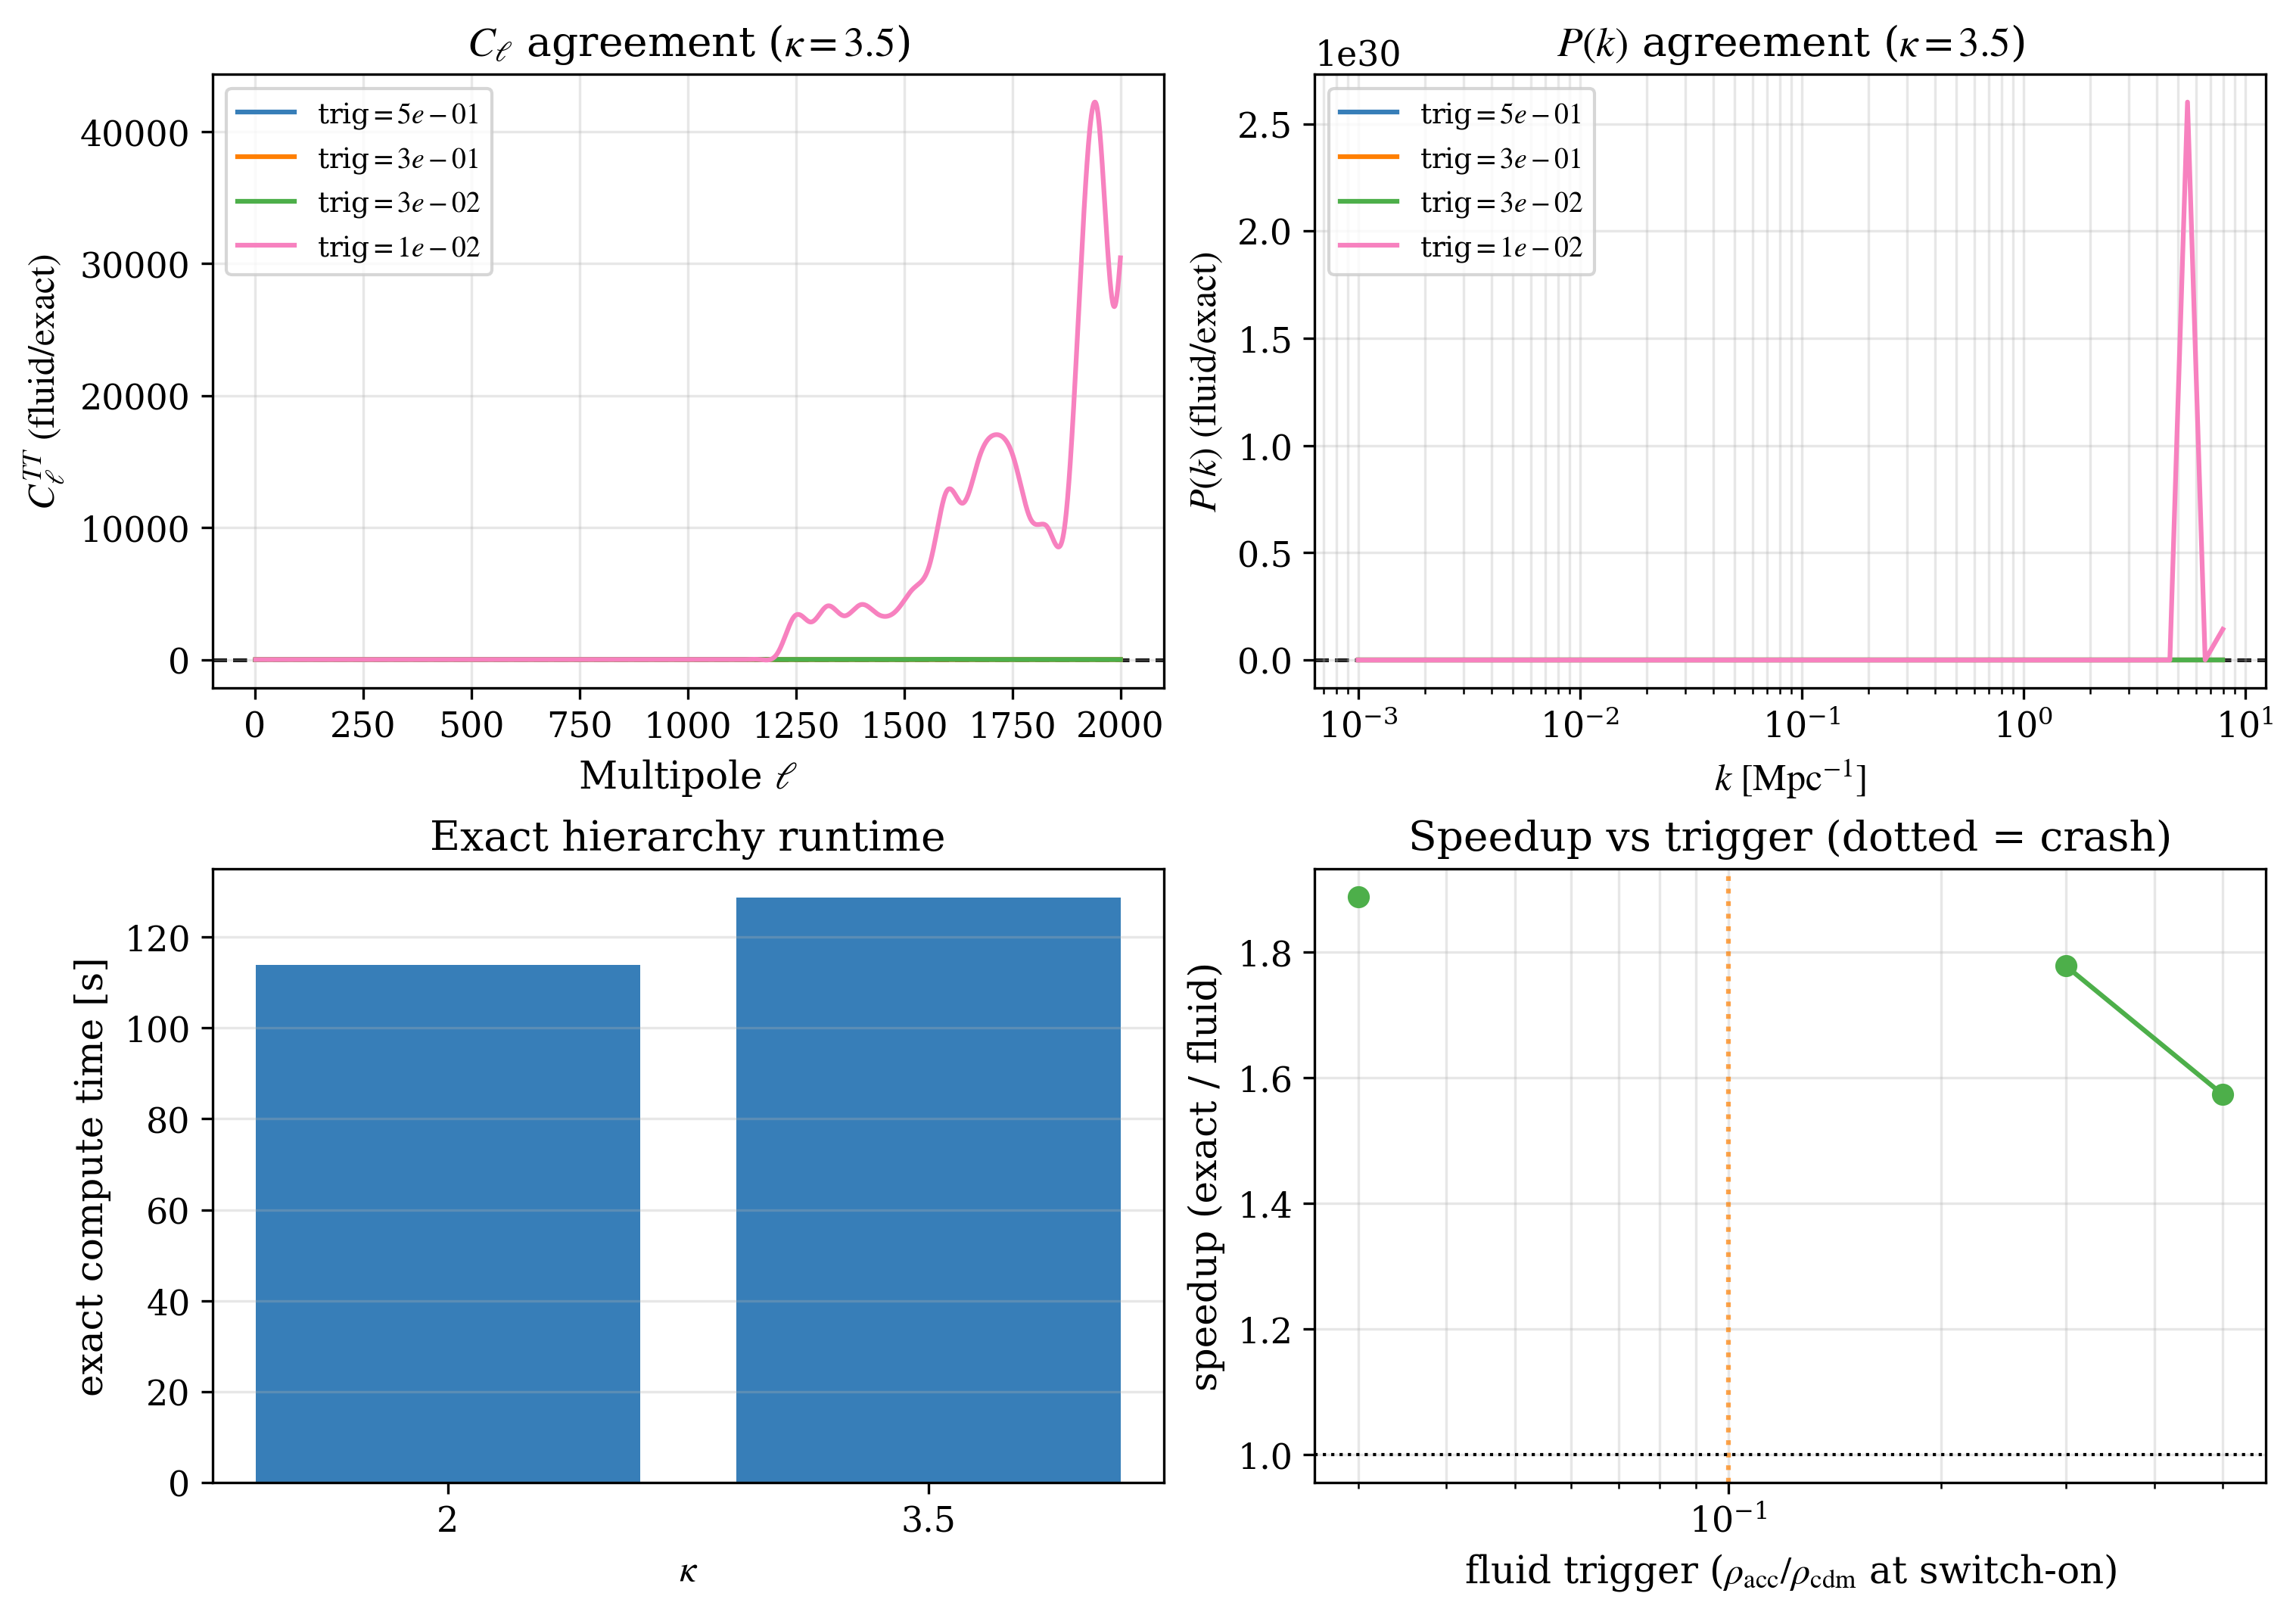

In [6]:
ok = [s for s in scan if s['obs'] is not None]
fig, axes = plt.subplots(2, 2, figsize=(10, 7), constrained_layout=True)

# (0,0) C_l TT ratio fluid/exact, for usable triggers
ax = axes[0, 0]
for s, c in zip(ok, qual_colors):
    ax.plot(ex_obs['ell'][m], s['obs']['tt'][m] / ex_obs['tt'][m],
            color=c, label=r'trig$=' + '{:.0e}$'.format(s['trig']))
ax.axhline(1.0, color='black', linestyle='--', linewidth=1.2, zorder=1)
ax.set_xlabel(r'Multipole $\ell$'); ax.set_ylabel(r'$C_\ell^{TT}\ (\mathrm{fluid}/\mathrm{exact})$')
ax.set_title(rf'$C_\ell$ agreement ($\kappa={KAP_SCAN}$)')
if ok: ax.legend(loc='best')
ax.grid(True, alpha=0.3)

# (0,1) P(k) ratio fluid/exact
ax = axes[0, 1]
for s, c in zip(ok, qual_colors):
    ax.semilogx(K_NODES, s['obs']['pk'] / ex_obs['pk'], color=c, label=r'trig$=' + '{:.0e}$'.format(s['trig']))
ax.axhline(1.0, color='black', linestyle='--', linewidth=1.2, zorder=1)
ax.set_xlabel(r'$k\ [\mathrm{Mpc}^{-1}]$'); ax.set_ylabel(r'$P(k)\ (\mathrm{fluid}/\mathrm{exact})$')
ax.set_title(rf'$P(k)$ agreement ($\kappa={KAP_SCAN}$)')
if ok: ax.legend(loc='best')
ax.grid(True, which='both', alpha=0.3)

# (1,0) exact runtime vs kappa
ax = axes[1, 0]
ax.bar([str(k) for k in KAPPAS], [exact[k][1] for k in KAPPAS], color=qual_colors[0])
ax.set_xlabel(r'$\kappa$'); ax.set_ylabel('exact compute time [s]')
ax.set_title('Exact hierarchy runtime'); ax.grid(True, axis='y', alpha=0.3)

# (1,1) speedup vs trigger (crashes marked)
ax = axes[1, 1]
trig_all = [s['trig'] for s in scan]
spd_all = [s.get('spd', np.nan) if s['obs'] is not None else np.nan for s in scan]
ax.semilogx(trig_all, spd_all, 'o-', color=qual_colors[2], label='speedup (where it ran)')
for s in scan:
    if s['obs'] is None:
        ax.axvline(s['trig'], color=qual_colors[1], linestyle=':', alpha=0.7)
ax.axhline(1.0, color='black', linestyle=':', linewidth=1.0)
ax.set_xlabel(r'fluid trigger ($\rho_{\mathrm{acc}}/\rho_{\mathrm{cdm}}$ at switch-on)')
ax.set_ylabel('speedup (exact / fluid)')
ax.set_title('Speedup vs trigger (dotted = crash)'); ax.grid(True, which='both', alpha=0.3)

plt.show()

### Notes
- **The exact hierarchy is the production path** - it runs for all `kappa`; panel (1,0) shows how its cost grows with `kappa` (sharper transition -> harder integration).
- **Fluid switch-on stiffness.** `ratio_rho ~ 1/trigger` at switch-on; with `rk` the converted->fluid transient is only resolvable when `ratio_rho` is `O(few)`, i.e. `trigger ~ 0.1-0.5`. By then the daughter is already a sizable fraction of the parent, so the exact hierarchy has done most of the work and the speedup is small. Smaller (useful) triggers crash (`step too small`). `ndf15` would absorb the stiffness but segfaults - so there is currently no fast, stable fluid path.
- **Agreement asserts are lenient** (`C_l < 2%`, `P(k) < 5%`) and only apply where the fluid ran; they catch a broken closure, not approximation-level differences.
- Take-away for the implementation: a usable fluid speedup needs either a stiff-capable evolver (fix `ndf15`) or a switch-on scheme that lands the daughter on the fluid attractor smoothly (so small triggers stop being stiff).
- pytest/nbmake: `pytest --nbmake notebooks_test/6_test_fluid_vs_exact.ipynb`.

## Phase 1: k-aware stiffness trigger (`kappa_stiff`)

The cells above use the **legacy density trigger** and show its failure modes: crash at `trigger=1e-1`, and a `P(k)` blow-up (`~1e21`) at `3e-2` from the unphysical-`ca2` regime.

Phase 1 replaces that k-independent gate with a **k-aware stiffness criterion**: the daughter switches exact→fluid only when `Lambda / max(aH, k*sqrt(ca2)) < kappa_stiff`, so the explicit `rk` evolver never sees the large decay-relaxation eigenvalue. The cells below verify `rk` now completes and agrees with the exact hierarchy, and (best-effort) record the stiffness ratio at switch-on for the **Phase-2 decision gate**.

Requires a CLASS build with the Phase-1 patch: the `kappa_stiff` precision parameter, the new gate in `perturbations_approximations`, and the switch-on log line. Phase 1 keeps the exact hierarchy on through the stiff phase, so its speedup is modest **by design** — the large speedup comes from Phase 2 (`acctca` daughter–parent slaving).

> **Capturing the switch-on log (Windows).** The verbose `stiffness ratio` lines are CLASS C-level `printf`s. The fd-redirect capture in the diagnostic cell is best-effort and frequently yields nothing on Windows (the `classy` DLL's CRT buffer is not the notebook process's). The **reliable** path on Windows is the `class` CLI: write the same parameters to a `.ini` with `perturbations_verbose = 3`, run `class file.ini`, and grep the console/log for `stiffness ratio`. Treat the in-notebook capture as a convenience, the CLI as the source of truth for the Phase-2 decision data.

In [ ]:
# --- Phase 1: the k-aware stiffness gate makes rk stable AND accurate ---
def accdm_fluid_kstiff(kappa, kappa_stiff, trigger=1e-6):
    """Fluid daughter via the NEW k-aware gate. The legacy density trigger is now
    unused for the daughter, so it is set tiny (early) on purpose: kappa_stiff
    alone decides switch-on."""
    p = accdm_params(kappa, 'fluid', trigger=trigger)
    p['kappa_stiff'] = kappa_stiff
    return p

TOL_CL_P1, TOL_PK_P1 = 2e-2, 7e-2
KSTIFF_VALUES = [3.0, 1.0, 0.3]
exc_obs, exc_t, _ = exact[KAP_SCAN]
m2 = exc_obs['ell'] >= 2

print('Phase 1: exact baseline at kappa={} is {:.1f}s'.format(KAP_SCAN, exc_t))
print('{:>11} {:>9} {:>9} {:>12} {:>12}'.format('kappa_stiff', 'time[s]', 'speedup', 'dev(Cl TT)', 'dev(P(k))'))
p1 = []
for ks in KSTIFF_VALUES:
    obs, t, err = run_timed(accdm_fluid_kstiff(KAP_SCAN, ks))
    if obs is None:
        print('{:>11.2g} {:>9} {:>9} {:>12} {:>12}'.format(ks, 'CRASH', '-', '-', '-'))
        p1.append({'ks': ks, 'obs': None, 'err': err})
        continue
    dcl = maxnorm(obs['tt'][m2], exc_obs['tt'][m2])
    dpk = relmax(obs['pk'], exc_obs['pk'])
    spd = exc_t / t
    p1.append({'ks': ks, 'obs': obs, 't': t, 'dcl': dcl, 'dpk': dpk, 'spd': spd})
    print('{:>11.2g} {:>9.1f} {:>8.1f}x {:>12.3e} {:>12.3e}'.format(ks, t, spd, dcl, dpk))
    assert dcl < TOL_CL_P1, 'Cl disagrees by {:.2e} at kappa_stiff={}'.format(dcl, ks)
    assert dpk < TOL_PK_P1, 'P(k) disagrees by {:.2e} at kappa_stiff={}'.format(dpk, ks)

assert any(s['obs'] is not None for s in p1), 'rk crashed at every kappa_stiff (expected stable)'
print('\nPhase 1 OK: rk completed and agreed with exact where tested.')
print('(Phase 1 keeps exact on through the stiff phase => modest speedup by design;')
print(' the large speedup is Phase 2 acctca slaving.)')

In [ ]:
# --- Phase 1 diagnostic (feeds the Phase-2 decision gate): stiffness ratio at switch-on ---
# Captures CLASS C-level stdout (printf) via fd redirection + libc fflush, since
# contextlib.redirect_stdout does NOT catch C-level output. On some platforms/builds
# the C buffer may not surface here; if the log is empty, run the `class` CLI on a
# .ini with `perturbations_verbose = 3` and parse the log for "stiffness ratio".
import os, re, ctypes, tempfile

def _libc_fflush():
    for name in ('msvcrt', 'libc.so.6', 'c'):
        try:
            ctypes.CDLL(name).fflush(None); return
        except OSError:
            continue
    try:
        ctypes.CDLL(None).fflush(None)
    except Exception:
        pass

def run_capture_stdout(params):
    M = Class(); M.set(params)
    saved = os.dup(1); tf = tempfile.TemporaryFile(mode='w+b'); err = None; t = None
    try:
        os.dup2(tf.fileno(), 1); t0 = time.perf_counter()
        try:
            M.compute(); t = time.perf_counter() - t0
        except Exception as e:
            t = time.perf_counter() - t0
            err = str(e).strip().splitlines()[-1] if str(e).strip() else type(e).__name__
    finally:
        _libc_fflush(); os.dup2(saved, 1); os.close(saved)
        tf.seek(0); log = tf.read().decode('utf-8', 'replace'); tf.close()
    try:
        M.struct_cleanup(); M.empty()
    except Exception:
        pass
    return t, err, log

_STIFF_RE = re.compile(r"Mode k=([-+0-9.eE]+):.*?stiffness ratio[^=]*=([-+0-9.eE]+)\)")

_p = accdm_fluid_kstiff(KAP_SCAN, 1.0); _p['perturbations_verbose'] = 3
_t, _err, _log = run_capture_stdout(_p)
_rows = _STIFF_RE.findall(_log)
if not _rows:
    print('No switch-on lines captured (CLASS C stdout not surfaced in this environment).')
    print('Fallback: write this param set to a .ini, run the `class` CLI with')
    print('perturbations_verbose = 3, and grep the log for "stiffness ratio".')
else:
    _ks = np.array([float(a) for a, _ in _rows]); _rs = np.array([float(b) for _, b in _rows])
    _o = np.argsort(_ks); _ks, _rs = _ks[_o], _rs[_o]
    print('transitions logged: {}; stiffness ratio at switch-on in [{:.2e}, {:.2e}]'.format(
        len(_rows), _rs.min(), _rs.max()))
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.loglog(_ks, _rs, 'o-', color=qual_colors[3])
    ax.axhline(1.0, color='black', ls='--', lw=1.0)
    ax.set_xlabel(r'$k\ [\mathrm{Mpc}^{-1}]$')
    ax.set_ylabel(r'$\Lambda/\max(aH,\,k c_s)$ at switch-on')
    ax.set_title(r'Daughter stiffness ratio at fluid switch-on ($\kappa={}$)'.format(KAP_SCAN))
    ax.grid(True, which='both', alpha=0.3); plt.show()